In [61]:
import pandas as pd
import numpy as np


merged_all_with_landcover = r"C:\Users\natal\Documents\UCLouvain\Data Science\Output_Sentinel5p\FINAL.csv"
df= pd.read_csv(merged_all_with_landcover)

In [62]:
df.head(20)

,grid_id,cell_id,x_min_m,y_min_m,x_max_m,y_max_m,month,ERA5__points_per_cell,ERA5__tmean,ERA5__tmin,...,OpenAQ_NO2__value,OpenAQ_NO2__points_per_cell,S5P_CO__avg,S5P_CO__points_per_cell,S5P_NO2__avg,S5P_NO2__points_per_cell,AOD_LandOcean,AOD_550_dark,AOD_DeepBlue,LANDCOVER
0,16372,r0105_c0000,8630000,880000,8640000,890000,1,0.0,25.882549,21.831293,...,NaN,NaN,NaN,NaN,0.000026,0.0,0.387,0.387,0.6725,19.666667
1,16372,r0105_c0000,8630000,880000,8640000,890000,1,0.0,25.882549,21.831293,...,NaN,NaN,NaN,NaN,0.000026,0.0,0.387,0.387,0.6725,19.666667
2,16372,r0105_c0000,8630000,880000,8640000,890000,10,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.590893
3,16372,r0105_c0000,8630000,880000,8640000,890000,2,0.0,26.866688,21.065729,...,NaN,NaN,NaN,NaN,0.000041,0.0,0.340,0.340,0.7565,19.666667
4,16372,r0105_c0000,8630000,880000,8640000,890000,2,0.0,26.866688,21.065729,...,NaN,NaN,NaN,NaN,0.000041,0.0,0.340,0.340,0.7565,19.666667
5,16372,r0105_c0000,8630000,880000,8640000,890000,3,0.0,27.744349,23.527384,...,NaN,NaN,NaN,NaN,NaN,NaN,0.413,0.413,0.6650,19.666667
6,16372,r0105_c0000,8630000,880000,8640000,890000,3,0.0,27.744349,23.527384,...,NaN,NaN,NaN,NaN,NaN,NaN,0.413,0.413,0.6650,19.666667
7,16372,r0105_c0000,8630000,880000,8640000,890000,4,0.0,27.953062,24.849009,...,NaN,NaN,NaN,0.0,0.000016,0.0,0.480,0.480,0.9280,19.666667
8,16372,r0105_c0000,8630000,880000,8640000,890000,4,0.0,27.953062,24.849009,...,NaN,NaN,NaN,0.0,0.000016,0.0,0.480,0.480,0.9280,19.666667
9,16372,r0105_c0000,8630000,880000,8640000,890000,5,0.0,27.910145,24.995203,...,NaN,NaN,0.032315,0.0,0.000018,0.0,0.370,0.370,0.8040,19.666667


In [63]:
print(df.notna().sum())

grid_id                        731861
cell_id                        731861
x_min_m                        731861
y_min_m                        731861
x_max_m                        731861
y_max_m                        731861
month                          731861
ERA5__points_per_cell          616304
ERA5__tmean                    607104
ERA5__tmin                     607104
ERA5__tmax                     607104
ERA5__prcp                     607104
ERA5__wind10m                  607104
ERA5__sp                       607104
ERA5__swdown                   607104
ERA5__imerg                    607104
ERA5__cloud                    379440
OpenAQ_CO__value                 6095
OpenAQ_CO__points_per_cell       6095
OpenAQ_NO2__value                4150
OpenAQ_NO2__points_per_cell      4150
S5P_CO__avg                    363652
S5P_CO__points_per_cell        385190
S5P_NO2__avg                   482590
S5P_NO2__points_per_cell       539266
AOD_LandOcean                  681634
AOD_550_dark

In [64]:
#Missing data stats
count_per_month_all_cols = df.groupby('month').count().reset_index()
print(count_per_month_all_cols)


   month  grid_id  cell_id  x_min_m  y_min_m  x_max_m  y_max_m  \
0      1    77038    77038    77038    77038    77038    77038   
1      2    77038    77038    77038    77038    77038    77038   
2      3    77038    77038    77038    77038    77038    77038   
3      4    77038    77038    77038    77038    77038    77038   
4      5    77038    77038    77038    77038    77038    77038   
5      6    77038    77038    77038    77038    77038    77038   
6      7    77038    77038    77038    77038    77038    77038   
7      8    77038    77038    77038    77038    77038    77038   
8      9    77038    77038    77038    77038    77038    77038   
9     10    38519    38519    38519    38519    38519    38519   

   ERA5__points_per_cell  ERA5__tmean  ERA5__tmin  ...  OpenAQ_NO2__value  \
0                  77038        75888       75888  ...                  0   
1                  77038        75888       75888  ...                308   
2                  77038        75888     

In [65]:
sub = df[df['OpenAQ_CO__value'].notna()].copy()
print("Training rows:", len(sub))

Training rows: 6095


In [66]:
sub

,grid_id,cell_id,x_min_m,y_min_m,x_max_m,y_max_m,month,ERA5__points_per_cell,ERA5__tmean,ERA5__tmin,...,OpenAQ_NO2__value,OpenAQ_NO2__points_per_cell,S5P_CO__avg,S5P_CO__points_per_cell,S5P_NO2__avg,S5P_NO2__points_per_cell,AOD_LandOcean,AOD_550_dark,AOD_DeepBlue,LANDCOVER
1712,16713,r0106_c0009,8640000,970000,8650000,980000,10,NaN,NaN,NaN,...,5.501000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.0
1713,16713,r0106_c0009,8640000,970000,8650000,980000,2,1.0,25.402031,16.563776,...,6.692857,1.0,NaN,NaN,0.000019,0.0,0.276,0.276,0.7565,33.0
1714,16713,r0106_c0009,8640000,970000,8650000,980000,2,1.0,25.402031,16.563776,...,6.692857,1.0,NaN,NaN,0.000019,0.0,0.276,0.276,0.7565,33.0
1715,16713,r0106_c0009,8640000,970000,8650000,980000,3,1.0,26.930525,19.330774,...,5.645600,1.0,NaN,NaN,NaN,NaN,0.327,0.327,0.6650,33.0
1716,16713,r0106_c0009,8640000,970000,8650000,980000,3,1.0,26.930525,19.330774,...,5.645600,1.0,NaN,NaN,NaN,NaN,0.327,0.327,0.6650,33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720152,7379,r0074_c0315,8320000,4030000,8330000,4040000,7,0.0,NaN,NaN,...,6.636667,1.0,0.029001,3.0,0.000025,4.0,0.329,0.329,0.9335,33.0
720153,7379,r0074_c0315,8320000,4030000,8330000,4040000,8,0.0,NaN,NaN,...,1.185238,1.0,0.027606,1.0,0.000021,4.0,0.310,0.310,0.8240,33.0
720154,7379,r0074_c0315,8320000,4030000,8330000,4040000,8,0.0,NaN,NaN,...,1.185238,1.0,0.027606,1.0,0.000021,4.0,0.310,0.310,0.8240,33.0
720155,7379,r0074_c0315,8320000,4030000,8330000,4040000,9,NaN,NaN,NaN,...,0.000000,1.0,NaN,NaN,NaN,NaN,0.212,0.212,0.7710,33.0


In [67]:
sub.columns

Index(['grid_id', 'cell_id', 'x_min_m', 'y_min_m', 'x_max_m', 'y_max_m',
       'month', 'ERA5__points_per_cell', 'ERA5__tmean', 'ERA5__tmin',
       'ERA5__tmax', 'ERA5__prcp', 'ERA5__wind10m', 'ERA5__sp', 'ERA5__swdown',
       'ERA5__imerg', 'ERA5__cloud', 'OpenAQ_CO__value',
       'OpenAQ_CO__points_per_cell', 'OpenAQ_NO2__value',
       'OpenAQ_NO2__points_per_cell', 'S5P_CO__avg', 'S5P_CO__points_per_cell',
       'S5P_NO2__avg', 'S5P_NO2__points_per_cell', 'AOD_LandOcean',
       'AOD_550_dark', 'AOD_DeepBlue', 'LANDCOVER'],
      dtype='object')

In [68]:
#CLEAN
features = [
    'MONTH',
    'AOD_LandOcean', #aod_land_ocean
    'ERA5__tmin', #temp_min
    'ERA5__tmin_log', #temp_min                   #LOG
    'AOD_550_dark', #aod_dark_target
    'AOD_DeepBlue_log', #aod_deep_blue_log        #LOG
    'S5P_NO2__avg_log', #s5p_no2_log              #LOG
    'ERA5__swdown', #solar_radiation
    'ERA5__swdown_log', #solar_radiation          #LOG
    'AOD_DeepBlue', #aod_deep_blue
    'ERA5__sp', #surface_pressure
    'ERA5__sp_log', #surface_pressure            #LOG
    'ERA5__prcp', #rainfall_imerg
    'AOD_550_dark_log', #aod_dark_target_log     #LOG
    'ERA5__wind10m', #wind_speed
    'ERA5__wind10m_log', #wind_speed_log         #LOG
    'AOD_LandOcean_log', #aod_land_ocean_log     #LOG
    'S5P_CO__avg', #sp5p_co               
    'ERA5__tmax', #temp_max
    'ERA5__tmax_log', #temp_max                  #LOG
    'ERA5__tmean', #temp_mean
    'ERA5__tmean_log', #temp_mean                #LOG
    'ERA5__prcp_log', #rainfall_imerg_log        #LOG
    'S5P_NO2__avg', #sp5p_no2
    'ERA5__cloud', #cloud_cover
    ##precip_log??
    'S5P_CO__avg_log', #sp5p_co_log              #LOG
    'LANDCOVER', #landcover
]

In [69]:
#NEW

import numpy as np

cols_to_log = [
    "AOD_DeepBlue",
    "S5P_NO2__avg",
    "AOD_550_dark",
    "AOD_LandOcean",
    "ERA5__prcp",
    "S5P_CO__avg",
    "ERA5__sp",
    "ERA5__wind10m",
    "ERA5__swdown",
    'ERA5__tmax', 
    'ERA5__tmean',
    'ERA5__tmin'
    
]

for col in cols_to_log:
    new_col = f"{col}_log"    # e.g., log_AOD_DeepBlue
    sub[new_col] = np.log1p(sub[col])


sub['log_NO2'] = np.log1p(sub['OpenAQ_NO2__value'])
sub['log_CO'] = np.log1p(sub['OpenAQ_CO__value'])

sub.columns

Index(['grid_id', 'cell_id', 'x_min_m', 'y_min_m', 'x_max_m', 'y_max_m',
       'month', 'ERA5__points_per_cell', 'ERA5__tmean', 'ERA5__tmin',
       'ERA5__tmax', 'ERA5__prcp', 'ERA5__wind10m', 'ERA5__sp', 'ERA5__swdown',
       'ERA5__imerg', 'ERA5__cloud', 'OpenAQ_CO__value',
       'OpenAQ_CO__points_per_cell', 'OpenAQ_NO2__value',
       'OpenAQ_NO2__points_per_cell', 'S5P_CO__avg', 'S5P_CO__points_per_cell',
       'S5P_NO2__avg', 'S5P_NO2__points_per_cell', 'AOD_LandOcean',
       'AOD_550_dark', 'AOD_DeepBlue', 'LANDCOVER', 'AOD_DeepBlue_log',
       'S5P_NO2__avg_log', 'AOD_550_dark_log', 'AOD_LandOcean_log',
       'ERA5__prcp_log', 'S5P_CO__avg_log', 'ERA5__sp_log',
       'ERA5__wind10m_log', 'ERA5__swdown_log', 'ERA5__tmax_log',
       'ERA5__tmean_log', 'ERA5__tmin_log', 'log_NO2', 'log_CO'],
      dtype='object')

In [70]:
#drop columns
cols_to_keep = [
    'month',
    #'AOD_LandOcean',
    'AOD_LandOcean_log',
    #'AOD_550_dark',
    'AOD_550_dark_log',
    #'AOD_DeepBlue',
    'AOD_DeepBlue_log',
    #'ERA5__prcp',
    'ERA5__prcp_log',
    #'S5P_CO__avg',
    'S5P_CO__avg_log',
    #'S5P_NO2__avg',
    'S5P_NO2__avg_log',
    #'ERA5__wind10m',
    'ERA5__wind10m_log',
    #ERA5__swdown',
    'ERA5__swdown_log',
    #'ERA5__sp',
    'ERA5__sp_log',
    #'ERA5__tmin',
    'ERA5__tmin_log',
    #'ERA5__tmax',
    'ERA5__tmax_log',
    #'ERA5__tmean',   
    'ERA5__tmean_log', 
    'ERA5__cloud',   #do not normalize categorical
    'LANDCOVER',
    'log_NO2',      #will be used to create y
    'log_CO',        #will be used to create y
    'OpenAQ_NO2__value',
    'OpenAQ_CO__value'
    
]

sub = sub[cols_to_keep].copy()

sub.columns

Index(['month', 'AOD_LandOcean_log', 'AOD_550_dark_log', 'AOD_DeepBlue_log',
       'ERA5__prcp_log', 'S5P_CO__avg_log', 'S5P_NO2__avg_log',
       'ERA5__wind10m_log', 'ERA5__swdown_log', 'ERA5__sp_log',
       'ERA5__tmin_log', 'ERA5__tmax_log', 'ERA5__tmean_log', 'ERA5__cloud',
       'LANDCOVER', 'log_NO2', 'log_CO', 'OpenAQ_NO2__value',
       'OpenAQ_CO__value'],
      dtype='object')

In [71]:
features = [col.replace("MONTH", "month") for col in features]

# Only keep columns that still exist in `sub`
features = [col for col in features if col in sub.columns]

for col in features:
    sub[col] = sub[col].fillna(sub[col].median())

sub.columns

Index(['month', 'AOD_LandOcean_log', 'AOD_550_dark_log', 'AOD_DeepBlue_log',
       'ERA5__prcp_log', 'S5P_CO__avg_log', 'S5P_NO2__avg_log',
       'ERA5__wind10m_log', 'ERA5__swdown_log', 'ERA5__sp_log',
       'ERA5__tmin_log', 'ERA5__tmax_log', 'ERA5__tmean_log', 'ERA5__cloud',
       'LANDCOVER', 'log_NO2', 'log_CO', 'OpenAQ_NO2__value',
       'OpenAQ_CO__value'],
      dtype='object')

In [72]:
X = sub[features]
#Create y for model for CO
y = sub['OpenAQ_CO__value']

In [73]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [51]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings("ignore")

In [52]:
#DONT RUN 
#ONLY RUN ONCE - TAKES 20min TO RUN
# ========== BAYESIAN OPTIMIZATION FOR RANDOM FOREST ==========
opt = BayesSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {
        "n_estimators": Integer(200, 1200),
        "max_depth": Integer(5, 40),
        "min_samples_split": Integer(2, 20),
        "min_samples_leaf": Integer(1, 10),
        "max_features": Real(0.3, 1.0),
        "bootstrap": [True, False],
    },
    n_iter=35,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=42
)

print("Running optimization on real ground stations...")
opt.fit(X_train, y_train)

# Evaluation
pred = opt.best_estimator_.predict(X_test)
print(f"→ Validation on real stations")
print(f"   MAE  : {mean_absolute_error(y_test, pred):.5f}")
print(f"   R²   : {r2_score(y_test, pred):.4f}")

Running optimization on real ground stations...
→ Validation on real stations
   MAE  : 0.06881
   R²   : 0.7526


In [ ]:
#DONT RUN again
print("Best Parameters:")
for k, v in opt.best_params_.items():
    print(f"{k}: {v}")

print("\nBest Estimator:")
print(opt.best_estimator_)

print("\nBest CV neg-MAE:", opt.best_score_)

Best Parameters:
bootstrap: False
max_depth: 39
max_features: 0.3
min_samples_leaf: 1
min_samples_split: 2
n_estimators: 1200

Best Estimator:
RandomForestRegressor(bootstrap=False, max_depth=39, max_features=0.3,
                      n_estimators=1200, n_jobs=-1, random_state=42)

Best CV neg-MAE: -0.10481316280115949


In [74]:
#Cross validation on training set
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 1. Define optimized model
rf_opt = RandomForestRegressor(
    n_estimators=1200,
    max_depth=39,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1,
    bootstrap=False,
    max_features=0.3,
    random_state=42
)

# 2. Cross-validation on training data only
cv_scores = cross_val_score(
    rf_opt,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

print("Cross-validation MAE scores:", -cv_scores)
print("Mean CV MAE:", -cv_scores.mean())

# 3. Fit model on full training data
rf_opt.fit(X_train, y_train)

# 4. Evaluate on test set
y_pred = rf_opt.predict(X_test)
print("R2 (log scale):", r2_score(y_test, y_pred))
print("RMSE (log scale):", np.sqrt(mean_squared_error(y_test, y_pred)))

# 5. Convert back to real scale
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred)

print("R2 (real scale):", r2_score(y_test_real, y_pred_real))
print("RMSE (real scale):", np.sqrt(mean_squared_error(y_test_real, y_pred_real)))


Cross-validation MAE scores: [0.10431465 0.10758112 0.10420376 0.11308471 0.09488157]
Mean CV MAE: 0.10481316280115949
R2 (log scale): 0.752599499874587
RMSE (log scale): 0.16477501222530822
R2 (real scale): 0.7770428272132015
RMSE (real scale): 0.3801727166101585


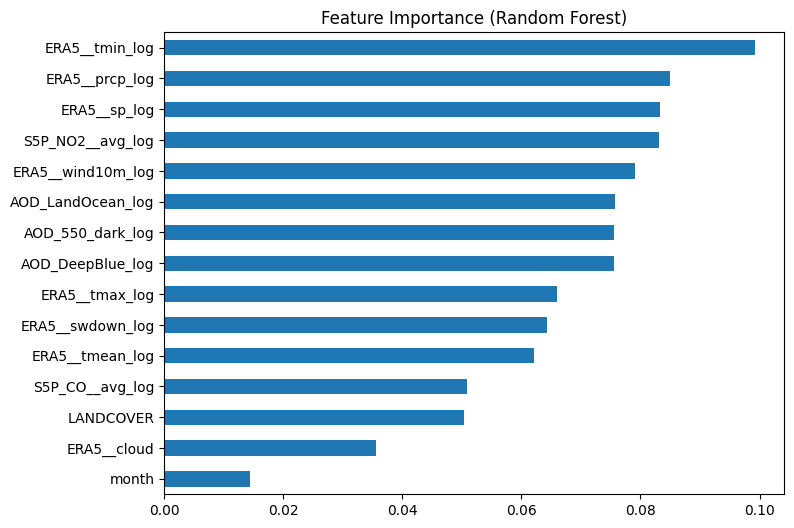

In [75]:
import matplotlib.pyplot as plt 

importances = pd.Series(rf_opt.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Random Forest)")
plt.show()

In [76]:
#Predict on full dataset
#1. create dataset to use for prediction 
df.columns

Index(['grid_id', 'cell_id', 'x_min_m', 'y_min_m', 'x_max_m', 'y_max_m',
       'month', 'ERA5__points_per_cell', 'ERA5__tmean', 'ERA5__tmin',
       'ERA5__tmax', 'ERA5__prcp', 'ERA5__wind10m', 'ERA5__sp', 'ERA5__swdown',
       'ERA5__imerg', 'ERA5__cloud', 'OpenAQ_CO__value',
       'OpenAQ_CO__points_per_cell', 'OpenAQ_NO2__value',
       'OpenAQ_NO2__points_per_cell', 'S5P_CO__avg', 'S5P_CO__points_per_cell',
       'S5P_NO2__avg', 'S5P_NO2__points_per_cell', 'AOD_LandOcean',
       'AOD_550_dark', 'AOD_DeepBlue', 'LANDCOVER'],
      dtype='object')

In [77]:
for col in cols_to_log:
    new_col = f"{col}_log"    # e.g., log_AOD_DeepBlue
    df[new_col] = np.log1p(df[col])


df['log_NO2'] = np.log1p(df['OpenAQ_NO2__value'])
df['log_CO'] = np.log1p(df['OpenAQ_CO__value'])


df = df[cols_to_keep].copy()

df.columns

Index(['month', 'AOD_LandOcean_log', 'AOD_550_dark_log', 'AOD_DeepBlue_log',
       'ERA5__prcp_log', 'S5P_CO__avg_log', 'S5P_NO2__avg_log',
       'ERA5__wind10m_log', 'ERA5__swdown_log', 'ERA5__sp_log',
       'ERA5__tmin_log', 'ERA5__tmax_log', 'ERA5__tmean_log', 'ERA5__cloud',
       'LANDCOVER', 'log_NO2', 'log_CO', 'OpenAQ_NO2__value',
       'OpenAQ_CO__value'],
      dtype='object')

In [78]:
print("Predicting rows:", df.shape)

Predicting rows: (731861, 19)


In [79]:
# Get the columns the model expects, in the right order
feature_order = rf_opt.feature_names_in_

# Select those columns from df in that order
X_pred = df[feature_order]

# Predict and add prediction column to df
df['prediction'] = rf_opt.predict(X_pred)

# Save entire dataframe with prediction column
df.to_csv(r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\predictions_CO_FINAL.csv", index=False)


In [80]:
#make df with columns, grid_id, month and prediction
merged_all_with_landcover = r"C:\Users\natal\Documents\UCLouvain\Data Science\Output_Sentinel5p\merged_all_FINAL.csv"
original_df= pd.read_csv(merged_all_with_landcover)

df_id_month = original_df[['grid_id', 'month']].copy()

# Append the prediction column to df_id_month
df_id_month['prediction'] = df['prediction']

# Check the final shape
print(df_id_month.shape)

# Export to csv
df_id_month.to_csv(r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\df_id_month_CO_FINAL.csv", index=False)


(731861, 3)


In [81]:
#Add coordinates for each cell 

import geopandas as gpd
# Path to GeoJSON grid file
grid = r"C:\Users\natal\Documents\UCLouvain\Data Science/india_grid_10x10km.geojson"
# Load into a GeoDataFrame
grid = gpd.read_file(grid)

# 1. Ensure grid_id in both dfs are same type (usually int)
df_id_month['grid_id'] = df_id_month['grid_id'].astype(int)
grid['grid_id'] = grid['grid_id'].astype(int)

# 2. Merge bounding box columns from grid onto df_id_month by grid_id
df_merged = df_id_month.merge(
    grid[['grid_id', 'x_min_m', 'y_min_m', 'x_max_m', 'y_max_m', 'geometry']],
    on='grid_id',
    how='left'
)

# 3. Convert df_merged to a GeoDataFrame with geometry column and grid CRS
gdf_merged = gpd.GeoDataFrame(df_merged, geometry='geometry', crs=grid.crs)

# 4. Export to GeoJSON
output_path = r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\predictions_CO_with_bbox_cleaned.geojson"
gdf_merged.to_file(output_path, driver='GeoJSON')

df_merged.drop(columns='geometry').to_csv(r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\predictions_CO_with_bbox_cleaned.csv", index=False)
print(f"✅ GeoJSON and cvs saved at {output_path}")

✅ GeoJSON and cvs saved at C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\predictions_CO_with_bbox_cleaned.geojson


In [82]:
#make separate file for each month

import os

# Folder to save GeoJSONs
prediction_output_folder = r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned"

# Make sure the folder exists
os.makedirs(prediction_output_folder, exist_ok=True)

# Check the exact column name for month (case sensitive)
print(df_merged.columns)  # e.g., it could be 'Month' or 'month'

# Convert to GeoDataFrame with geometry and CRS from your grid
gdf_merged = gpd.GeoDataFrame(df_merged, geometry='geometry', crs=grid.crs)

# Let's assume it's 'Month' based on your earlier code
month_col = 'month'  # change if needed

# Get unique months
months = gdf_merged[month_col].unique()

# Loop through months and save separate GeoJSONs
for month in months:
    subset = gdf_merged[gdf_merged[month_col] == month]
    
    # Filename with zero-padded month number, e.g., 01, 02, ...
    filename = f"CO_month_{int(month):02d}.geojson"
    
    # Full path
    filepath = os.path.join(prediction_output_folder, filename)
    
    # Save GeoJSON
    subset.to_file(filepath, driver='GeoJSON')
    
    print(f"Saved month {month} to {filepath}")



Index(['grid_id', 'month', 'prediction', 'x_min_m', 'y_min_m', 'x_max_m',
       'y_max_m', 'geometry'],
      dtype='object')
Saved month 1 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_01.geojson
Saved month 10 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_10.geojson
Saved month 2 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_02.geojson
Saved month 3 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_03.geojson
Saved month 4 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_04.geojson
Saved month 5 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_05.geojson
Saved month 6 to C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_06.geojson
Saved month 7 to C:\Users\natal\Documen

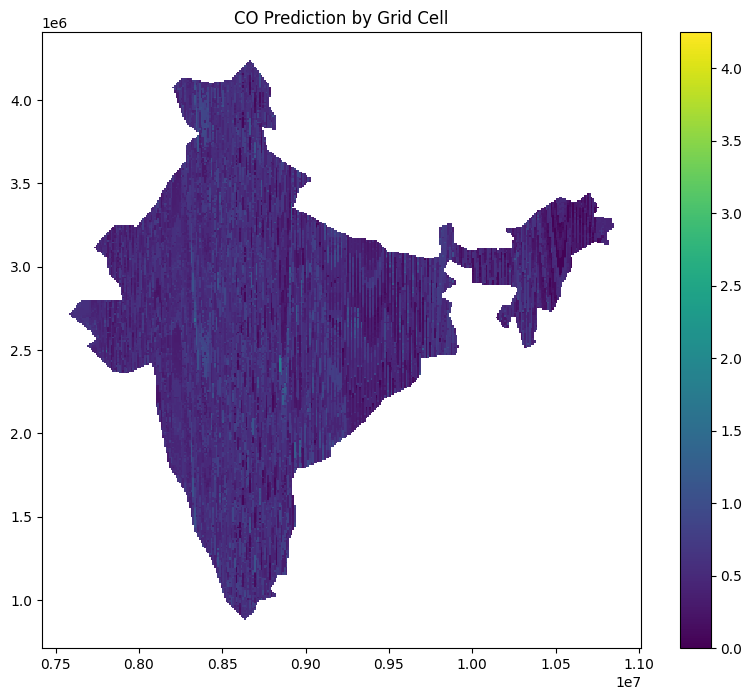

In [88]:

merged_all_with_landcover = r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_01.geojson"
gdf_1= gpd.read_file(merged_all_with_landcover)

df = gdf_1.copy()

import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

# Load your CSV (assuming it contains x_min_m, y_min_m, x_max_m, y_max_m, ERA5__tmean)
df = gdf_merged.copy()

# Function to build a rectangle polygon from min/max coords
def build_polygon(row):
    return Polygon([
        (row['x_min_m'], row['y_min_m']),
        (row['x_max_m'], row['y_min_m']),
        (row['x_max_m'], row['y_max_m']),
        (row['x_min_m'], row['y_max_m'])
    ])

# Create geometry column
df['geometry'] = df.apply(build_polygon, axis=1)

# Convert to GeoDataFrame (set CRS if known, otherwise leave it blank)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:3857")  # example CRS

# Plot ERA5 temperature as choropleth
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(
    column="prediction",
    cmap="viridis",       # you can change colormap
    legend=True,
    edgecolor="none",
    ax=ax
)

ax.set_title("CO Prediction by Grid Cell")
plt.show()

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import imageio
import os

# ---------------------------------------
# 1. Define folder and list of geojsons
# ---------------------------------------
folder = r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned"

# Example naming: NO2_month_01.geojson ... NO2_month_10.geojson
files = [f"CO_month_{str(i).zfill(2)}.geojson" for i in range(1, 11)]

# Build full paths
file_paths = [os.path.join(folder, f) for f in files]

# ---------------------------------------
# 2. Output folder for temporary PNG frames
# ---------------------------------------
frames_dir = os.path.join(folder, "frames")
os.makedirs(frames_dir, exist_ok=True)

# ---------------------------------------
# 3. Load each file, plot, and save PNG
# ---------------------------------------
frame_paths = []

for i, path in enumerate(file_paths, start=1):
    print(f"Processing: {path}")
    
    gdf = gpd.read_file(path)

    # Create figure
    fig, ax = plt.subplots(figsize=(7, 7))
    gdf.plot(column="prediction", cmap="viridis", legend=True, ax=ax)
    
    ax.set_title(f"NO2 Prediction — Month {i}", fontsize=16)
    ax.axis("off")

    # Save frame
    frame_path = os.path.join(frames_dir, f"frame_{i:02d}.png")
    plt.savefig(frame_path, dpi=150, bbox_inches="tight")
    plt.close()

    frame_paths.append(frame_path)

# ---------------------------------------
# 4. Make GIF
# ---------------------------------------
gif_path = os.path.join(folder, "time_series_CO.gif")

with imageio.get_writer(gif_path, mode="I", duration=0.7) as writer:
    for frame in frame_paths:
        image = imageio.imread(frame)
        writer.append_data(image)

print("GIF saved at:", gif_path)


Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_01.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_02.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_03.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_04.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_05.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_06.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_07.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\CO_month_08.geojson
Processing: C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cl

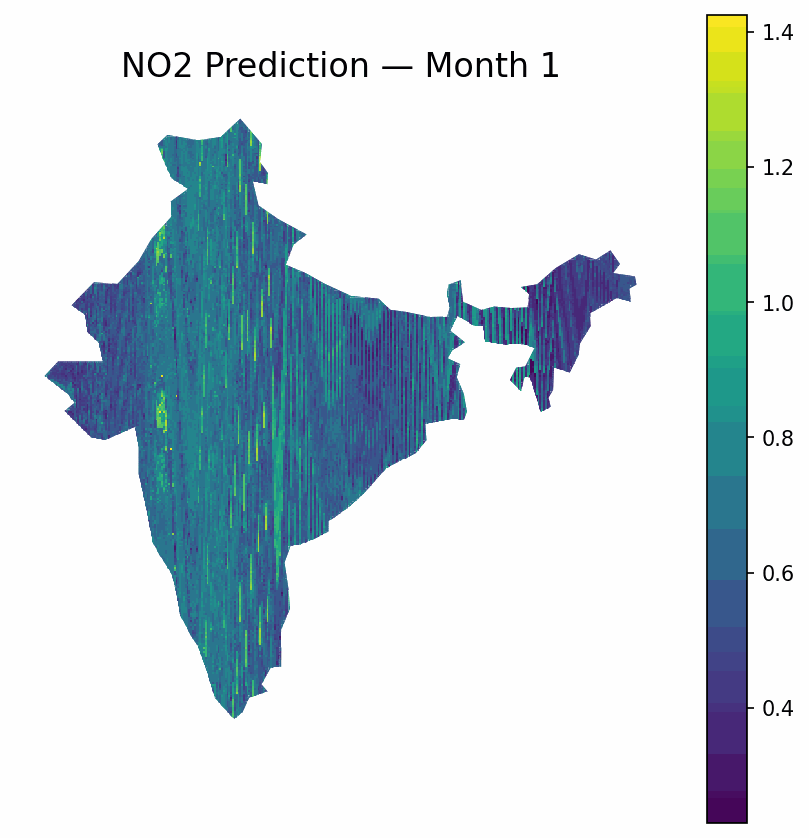

In [95]:
from IPython.display import Image

Image(filename=r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\Predictions\CO_cleaned\time_series_NO2.gif")

In [29]:
#DONT RUN AGAIN
#Bbox the prediction file

import geopandas as gpd
# Path to GeoJSON grid file
grid = r"C:\Users\natal\Documents\UCLouvain\Data Science/india_grid_10x10km.geojson"
# Load into a GeoDataFrame
grid = gpd.read_file(grid)

df_id_month = pd.read_csv(r"C:\Users\natal\Documents\UCLouvain\Data Science\Output_Sentinel5p\merged_all_FINAL.csv")
# 1. Ensure grid_id in both dfs are same type (usually int)
df_id_month['grid_id'] = df_id_month['grid_id'].astype(int)
grid['grid_id'] = grid['grid_id'].astype(int)

# 2. Merge bounding box columns from grid onto df_id_month by grid_id
df_merged = df_id_month.merge(
    grid[['grid_id', 'x_min_m', 'y_min_m', 'x_max_m', 'y_max_m', 'geometry']],
    on='grid_id',
    how='left'
)

# 3. Convert df_merged to a GeoDataFrame with geometry column and grid CRS
gdf_merged = gpd.GeoDataFrame(df_merged, geometry='geometry', crs=grid.crs)

# 4. Export to GeoJSON
output_path = r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\merged_all_FINAL_pred_bbox.geojson"
gdf_merged.to_file(output_path, driver='GeoJSON')

df_merged.drop(columns='geometry').to_csv(r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\merged_all_FINAL_pred_bbox.csv", index=False)
print(f"✅ GeoJSON and cvs saved at {output_path}")


✅ GeoJSON and cvs saved at C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\merged_all_FINAL_pred_bbox.geojson


In [ ]:
#TRY - dont run
import geopandas as gpd
import pandas as pd

# Path to GeoJSON grid file
grid = r"C:\Users\natal\Documents\UCLouvain\Data Science\india_grid_10x10km.geojson"
grid = gpd.read_file(grid)

# Load CSV
df_id_month = pd.read_csv(
    r"C:\Users\natal\Documents\UCLouvain\Data Science\Output_Sentinel5p\merged_all_FINAL.csv"
)

# Ensure grid_id is int
df_id_month['grid_id'] = df_id_month['grid_id'].astype(int)
grid['grid_id'] = grid['grid_id'].astype(int)

# Merge bbox columns + geometry
df_merged = df_id_month.merge(
    grid[['grid_id', 'x_min_m', 'y_min_m', 'x_max_m', 'y_max_m', 'geometry']],
    on='grid_id',
    how='left'
)

# Convert to GeoDataFrame
gdf_merged = gpd.GeoDataFrame(df_merged, geometry='geometry', crs=grid.crs)

# -------- KEEP ONLY DESIRED COLUMNS -------- #
cols_to_keep = [
    'grid_id',
    'ERA5__tmean',
    'x_min_m',
    'y_min_m',
    'x_max_m',
    'y_max_m',
    'geometry'
]

gdf_subset = gdf_merged[cols_to_keep]

# -------- EXPORT -------- #
output_path = r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\merged_all_FINAL_pred_bbox_2.geojson"
gdf_subset.to_file(output_path, driver='GeoJSON')

# CSV without geometry 
gdf_subset.drop(columns='geometry').to_csv(
    r"C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\merged_all_FINAL_pred_bbox_2.csv",
    index=False   
)
  
print(f"✅ GeoJSON and CSV saved at {output_path}") 


✅ GeoJSON and CSV saved at C:\Users\natal\Documents\UCLouvain\Data Science\Land_Cover\merged_all_FINAL_pred_bbox.geojson


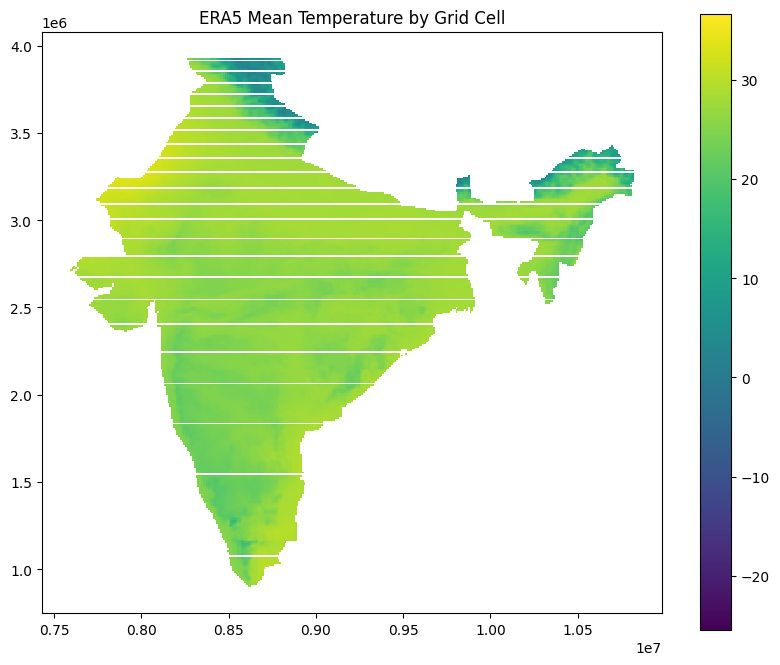

In [ ]:
#DOnt need to run

import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

# Load your CSV (assuming it contains x_min_m, y_min_m, x_max_m, y_max_m, ERA5__tmean)
df = gdf_merged.copy()

# Function to build a rectangle polygon from min/max coords
def build_polygon(row):
    return Polygon([
        (row['x_min_m'], row['y_min_m']),
        (row['x_max_m'], row['y_min_m']),
        (row['x_max_m'], row['y_max_m']),
        (row['x_min_m'], row['y_max_m'])
    ])

# Create geometry column
df['geometry'] = df.apply(build_polygon, axis=1)

# Convert to GeoDataFrame (set CRS if known, otherwise leave it blank)
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:3857")  # example CRS

# Plot ERA5 temperature as choropleth
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(
    column="ERA5__tmean",
    cmap="viridis",       # you can change colormap
    legend=True,
    edgecolor="none",
    ax=ax
)

ax.set_title("ERA5 Mean Temperature by Grid Cell")
plt.show()
